In [20]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scvi
from sklearn.metrics import classification_report
from scarches.models.scpoli import scPoli
from scarches.dataset.trvae.data_handling import remove_sparsity

import warnings
warnings.filterwarnings('ignore')

# 设置参数
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (4, 4)
sc.settings.seed = 42

 captum (see https://github.com/pytorch/captum).


In [3]:
adata1 = sc.read_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/label_transfer/without_invitro_adult_n_epochs100_dim128_cellranger/combined_samples.h5ad")
adata2 = sc.read_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/label_transfer/without_invitro_adult_n_epochs200_dim128_cellranger/combined_samples.h5ad")

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
import pandas as pd
# 查看dataset和lineage的交叉分布
cross_tab = pd.crosstab(adata.obs['dataset'], adata.obs['lineage'])
cross_tab

lineage,8C,Amniotic_ecto,Astrocyte,Choroid plexus,Endoderm,Ependymal,Erythrocyte,ExE_endo,Fibroblast,Glioblast,Immune,Inner Cell Mass,Microglia,Morula,NMP,Neural crest,Neuroblast,Neuron,Neuronal IPC,Notochord,OPC,Oligo,PGC,Placodes,Prelineage,Primitive.streak,Radial glia,TE_TrB,Vascular,epi,hemogenic,meso_Exe.meso,neural_ecto
dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
adult,0,0,15072,812,0,543,0,0,744,0,346,0,8488,0,0,0,0,228954,0,0,9781,45743,0,0,0,0,0,0,918,0,0,0,0
fetal,0,0,0,0,0,0,824,0,1764,12192,745,0,0,0,0,80,26301,51719,10149,0,0,569,0,80,0,0,47865,0,1081,0,0,0,0
pre,30,321,0,0,145,0,0,755,0,0,0,88,0,19,812,0,0,0,0,91,0,0,10,0,39,167,0,15935,0,2340,1002,11466,1957


In [12]:
filtered_adata = adata[adata.obs['dataset'].isin(['fetal', 'pre'])].copy()

In [14]:
filtered_adata.write_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/output/combined_sampled_fetal_pre.h5ad")

In [5]:
adata1.obsm['X_umap']=adata1.obsm['X_umap_lineage']
adata2.obsm['X_umap']=adata2.obsm['X_umap_lineage']

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


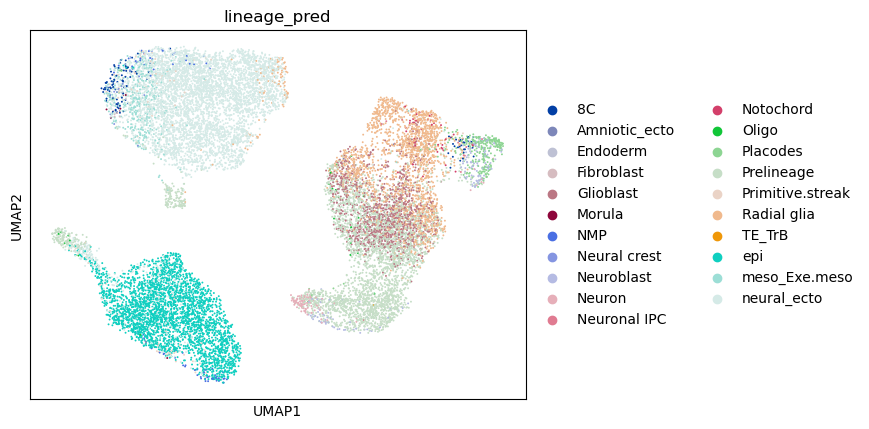

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


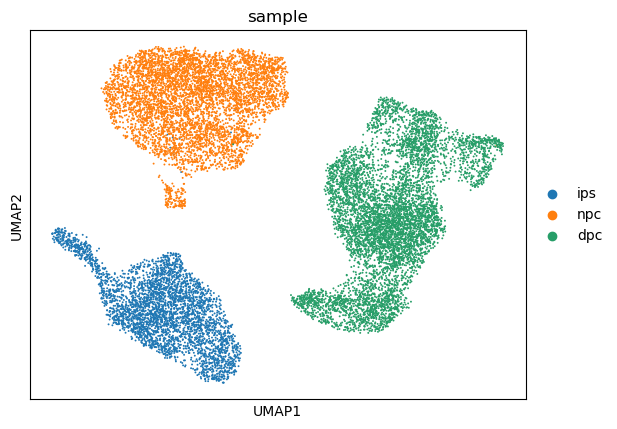

In [6]:
sc.pl.umap(adata1,color='lineage_pred')
sc.pl.umap(adata1,color='sample')

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


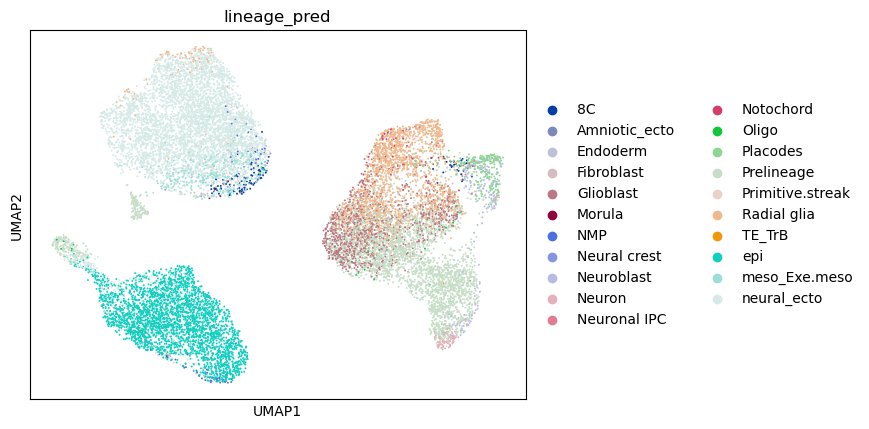

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


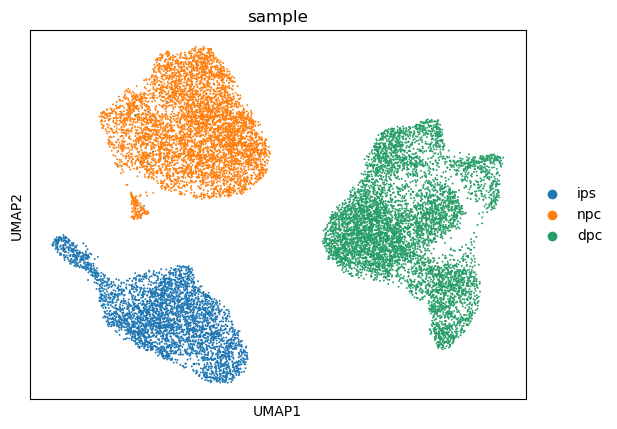

In [7]:
sc.pl.umap(adata2,color='lineage_pred')
sc.pl.umap(adata2,color='sample')

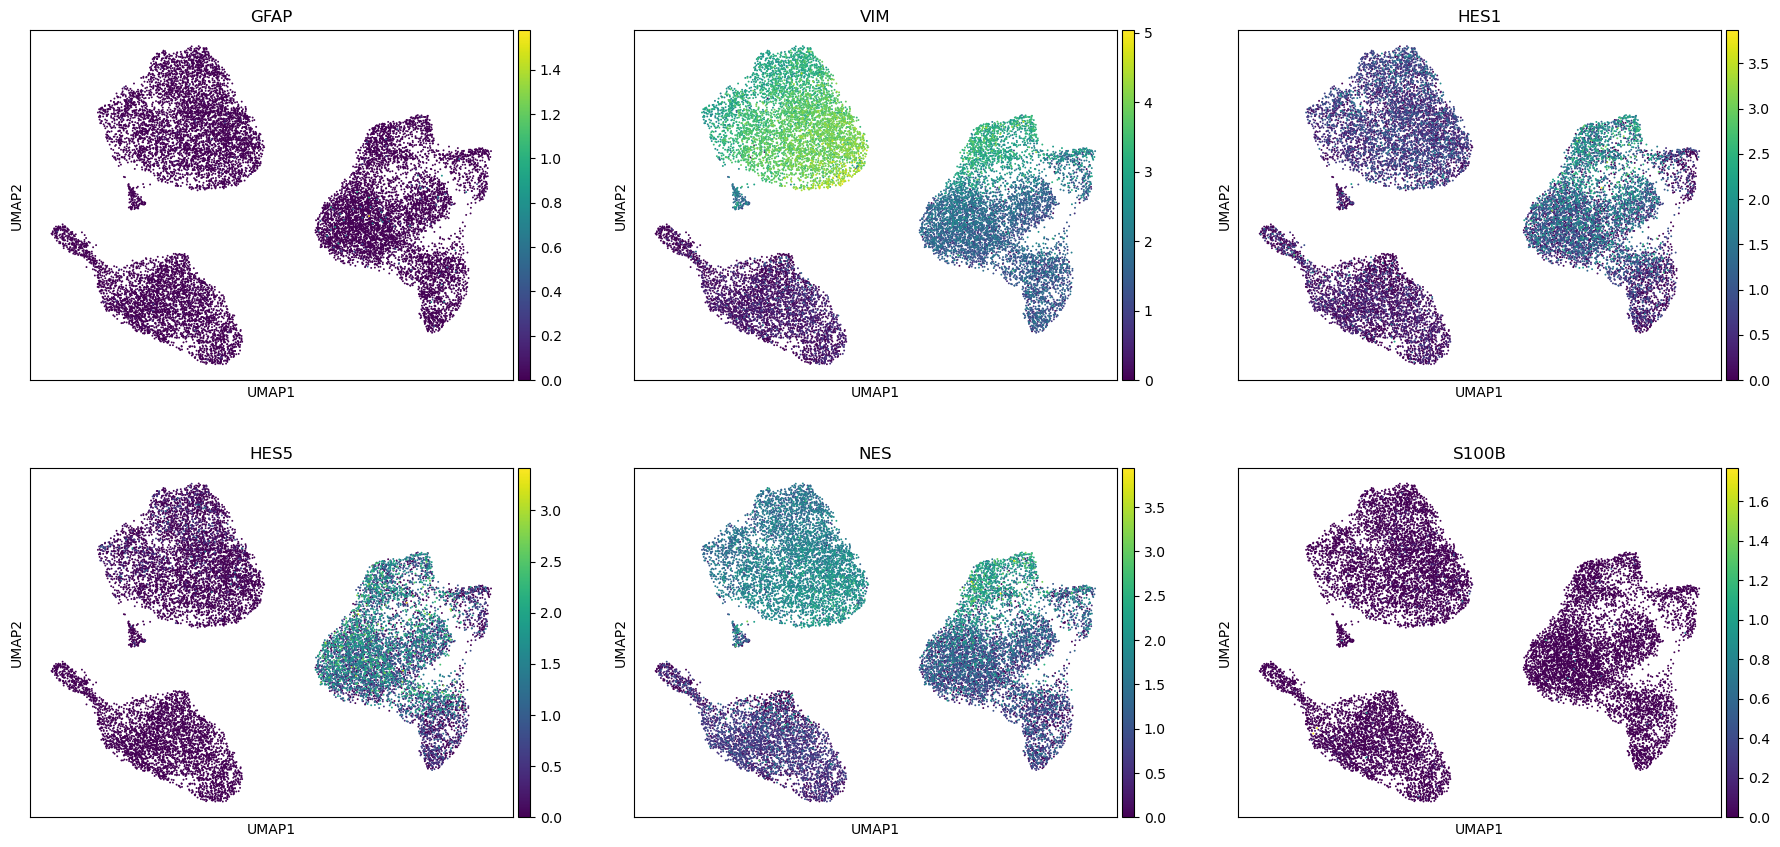

In [8]:
radial_glia_markers = [
    'GFAP',       # 胶质纤维酸性蛋白 - 最经典
    'VIM',        # 波形蛋白 - 细胞骨架
    'HES1',       # Notch信号通路
    'HES5',       # Notch信号通路
    'NES',        # 巢蛋白
    'S100B'       # 钙结合蛋白
]

# 绘制每个基因的UMAP图
sc.pl.umap(adata2, color=radial_glia_markers, ncols=3, show=True)

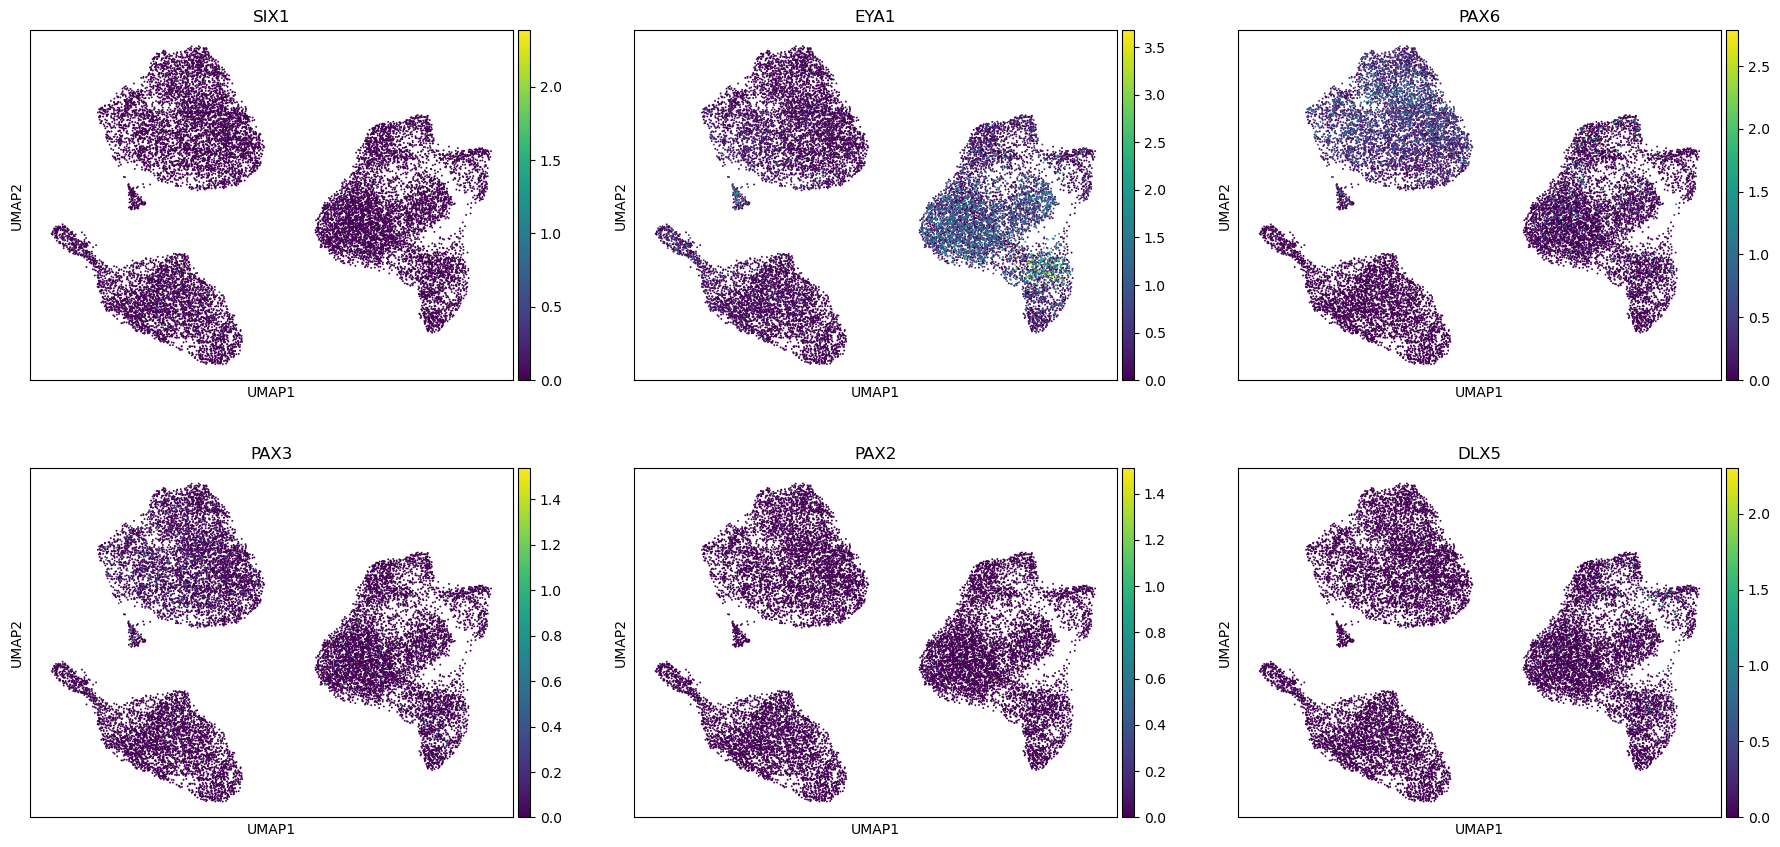

In [10]:
placode_markers = [
    'SIX1',       # 感觉基板关键转录因子
    'EYA1',       # 与SIX1相互作用
    'PAX6',       # 眼和鼻基板
    'PAX3',       # 神经嵴和基板发育
    'PAX2',       # 耳基板
    'DLX5',       # 颅面发育
]
# 绘制每个基因的UMAP图
sc.pl.umap(adata2, color=placode_markers, ncols=3, show=True)

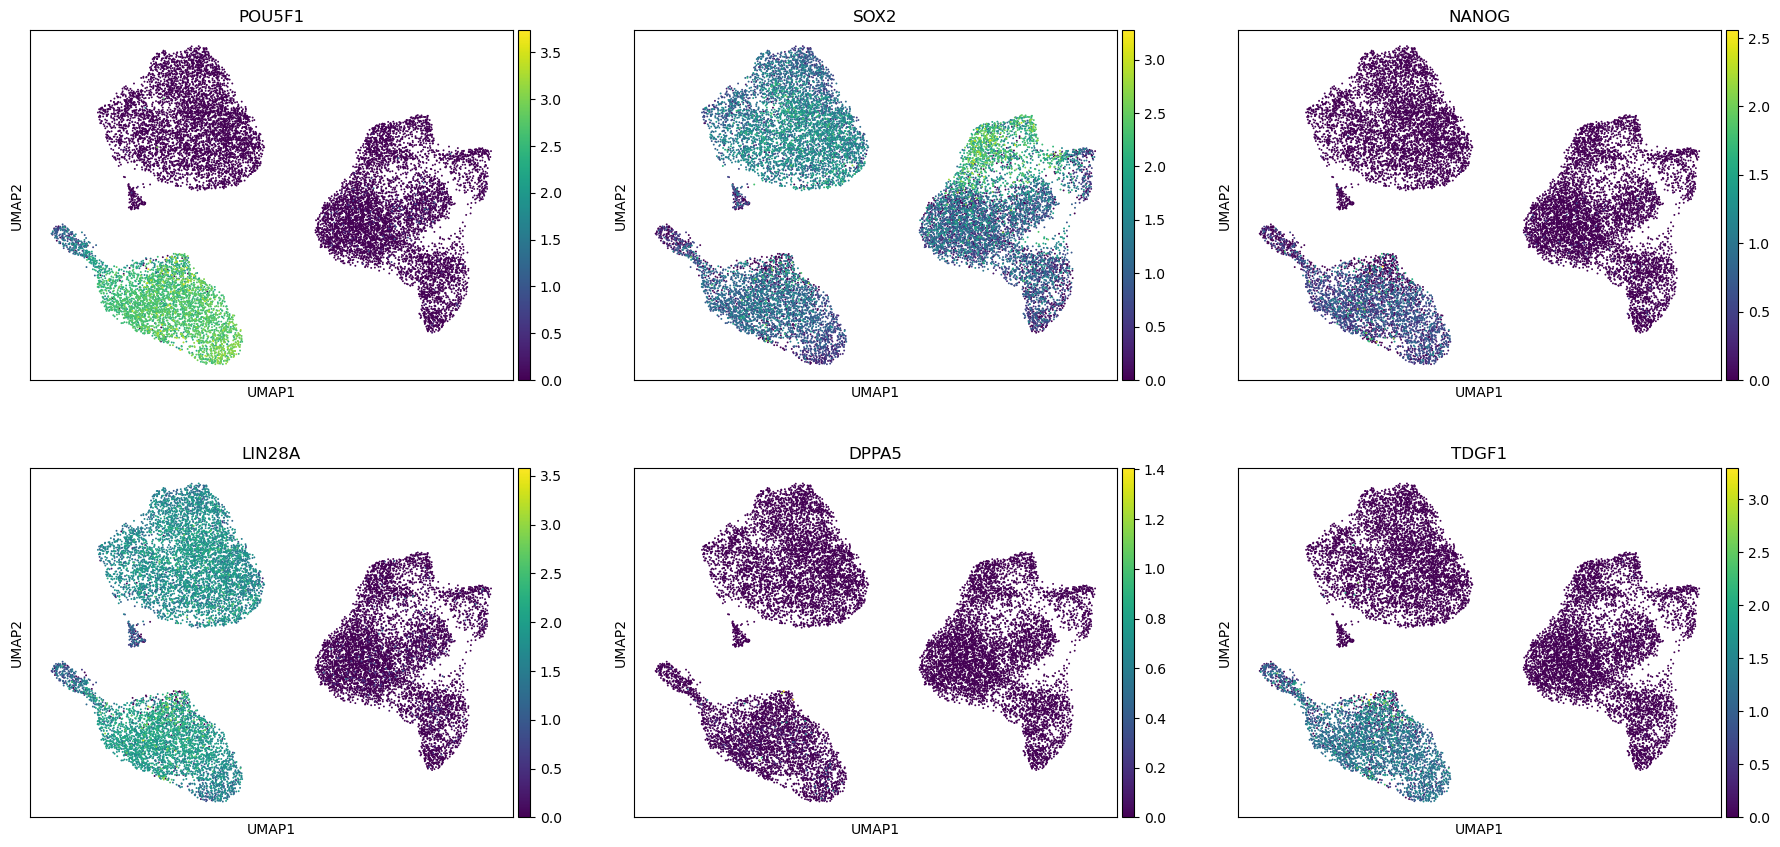

In [11]:
prelineage_markers = [
    'POU5F1',     # OCT4 - 多能性关键因子
    'SOX2',       # 与OCT4协同作用
    'NANOG',      # 多能性维持
    'LIN28A',     # 多能性相关
    'DPPA5',      # 发育多能性相关基因
    'TDGF1',      # CRIPTO - 多能性标记
]
sc.pl.umap(adata2, color=prelineage_markers, ncols=3, show=True)

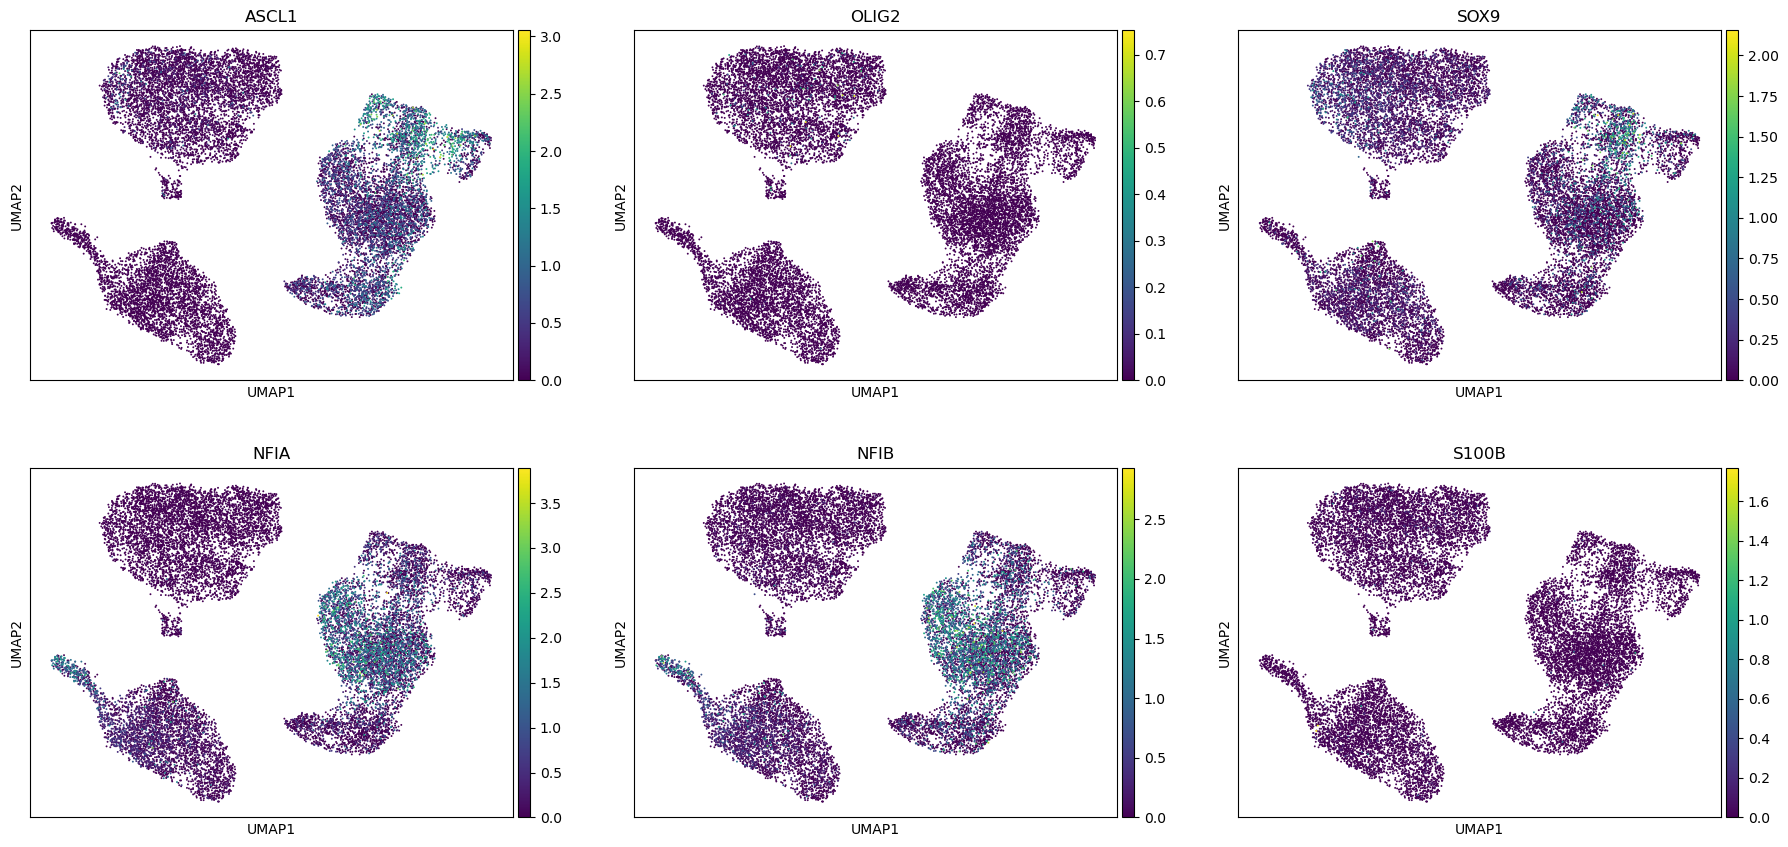

In [12]:
glioblast_markers = [
    'ASCL1',      # 胶质发生相关
    'OLIG2',      # 少突胶质和部分星形胶质前体
    'SOX9',       # 胶质命运决定
    'NFIA',       # 胶质发生关键因子
    'NFIB',       # 与NFIA协同
    'S100B',      # 胶质细胞成熟标记
]
sc.pl.umap(adata1, color=glioblast_markers, ncols=3, show=True)

In [13]:
adata=sc.read_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/model/without_invitro_adult_n_epochs200_dim128_cellranger/scpoli_model_lineage_hvg2000/adata.h5ad")

In [28]:
filter_combine=sc.read_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/output/combined_sampled_optimized_counts.h5ad")

In [23]:
adata

AnnData object with n_obs × n_vars = 188546 × 2000
    obs: 'stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage', 'dataset', 'conditions_combined'
    obsm: 'X_umap'
    layers: 'counts'

In [29]:
adult_adata = filter_combine[filter_combine.obs['orig.ident'] == 'Kimberly Siletti'].copy()

In [30]:
adult_adata

AnnData object with n_obs × n_vars = 311401 × 29772
    obs: 'stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage', 'dataset'
    obsm: 'X_umap'
    layers: 'counts'

In [31]:
filter_combine

AnnData object with n_obs × n_vars = 499947 × 29772
    obs: 'stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage', 'dataset'
    obsm: 'X_umap'
    layers: 'counts'

In [34]:
combined_adata = sc.concat(
    [adata, adult_adata],
    join='inner',  # 只保留共同基因
    label='orig.ident'
)

print(f"合并前 - 你的数据: {adata.n_obs} 细胞, {adata.n_vars} 基因")
print(f"合并前 - Adult数据: {adult_adata.n_obs} 细胞, {adult_adata.n_vars} 基因")
print(f"合并后: {combined_adata.n_obs} 细胞, {combined_adata.n_vars} 基因")

合并前 - 你的数据: 188546 细胞, 2000 基因
合并前 - Adult数据: 311401 细胞, 29772 基因
合并后: 499947 细胞, 2000 基因


In [48]:
# === scPoli 整合 ===
print("\n=== scPoli 整合 ===")

enhanced_model_dir = '/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/model/without_invitro_with_adult_finetuning_n_epochs_100'
# 设置scPoli参数
condition_key = "orig.ident"  # 批次/条件信息
cell_type_key = "lineage"  # 细胞类型信息

print(f"条件变量: {condition_key}")
print(f"细胞类型变量: {cell_type_key}")
print(f"条件分布: {combined_adata.obs[condition_key].value_counts()}")
print(f"细胞类型分布: {combined_adata.obs[cell_type_key].value_counts()}")

# 早期停止参数
early_stopping_kwargs = {
    "early_stopping_metric": "val_prototype_loss",
    "mode": "min", 
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

# 训练scPoli模型
print("训练scPoli模型...")

scpoli_model = scPoli(
    adata=combined_adata,
    condition_keys=condition_key,
    cell_type_keys=cell_type_key, 
    embedding_dims=20,
    recon_loss='nb',
)

scpoli_model.train(
    n_epochs=100,
    pretraining_epochs=40,
    early_stopping_kwargs=early_stopping_kwargs,
    eta=5,
)

# Fix numeric columns stored as strings
numeric_cols = ['nCount_RNA', 'nFeature_RNA', 'percent.mt']
for col in numeric_cols:
    if col in combined_adata.obs.columns:
        combined_adata.obs[col] = pd.to_numeric(combined_adata.obs[col], errors='coerce')

# Fix remaining object columns
for col in combined_adata.obs.columns:
    if combined_adata.obs[col].dtype == 'object':
        # Try category first (ideal for AnnData)
        if combined_adata.obs[col].nunique() / len(combined_adata) < 0.5:  # heuristic
            combined_adata.obs[col] = combined_adata.obs[col].astype('category')
        else:
            combined_adata.obs[col] = combined_adata.obs[col].astype('string')

# Now save
try:
    print("Saving the enhanced model...")
    scpoli_model.save(enhanced_model_dir, overwrite=True, save_anndata=True)
    print(f"✅ Enhanced model saved to {enhanced_model_dir}")
except Exception as e:
    print(f"❌ Error: {e}")






=== scPoli 整合 ===
条件变量: orig.ident
细胞类型变量: lineage
条件分布: orig.ident
1    311401
0    188546
Name: count, dtype: int64
细胞类型分布: lineage
Neuron              280673
Radial glia          47865
Oligo                46312
Neuroblast           26301
TE_TrB               15935
Astrocyte            15072
Glioblast            12192
meso_Exe.meso        11466
Neuronal IPC         10149
OPC                   9781
Microglia             8488
Fibroblast            2508
epi                   2340
Vascular              1999
neural_ecto           1957
Immune                1091
hemogenic             1002
Erythrocyte            824
Choroid plexus         812
NMP                    812
ExE_endo               755
Ependymal              543
Amniotic_ecto          321
Primitive.streak       167
Endoderm               145
Notochord               91
Inner Cell Mass         88
Placodes                80
Neural crest            80
Prelineage              39
8C                      30
Morula                  19
P

INFO:scarches.trainers.scpoli.trainer:GPU available: False


Initializing dataloaders
Starting training
 |██████████████████--| 93.0%  - val_loss: 1081.88 - val_cvae_loss: 1072.39 - val_prototype_loss:    9.48 - val_labeled_loss:    1.90
ADJUSTED LR
 |████████████████████| 100.0%  - val_loss: 1082.28 - val_cvae_loss: 1072.81 - val_prototype_loss:    9.47 - val_labeled_loss:    1.89

Stopping early: no improvement of more than 0 nats in 20 epochs
If the early stopping criterion is too strong, please instantiate it with different parameters in the train method.
Saving the enhanced model...
✅ Enhanced model saved to /storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/model/without_invitro_with_adult_finetuning_n_epochs_100


In [49]:
# 获取scPoli潜在表示
print("获取scPoli潜在表示...")
scpoli_model.model.eval()
if hasattr(combined_adata.X, 'toarray'):
    combined_adata.X = combined_adata.X.toarray()
data_latent_source  = scpoli_model.get_latent(combined_adata,mean=True)
combined_adata.obsm["scPoli"] = data_latent_source
# 基于scPoli的聚类和UMAP
print("基于scPoli的聚类...")
sc.pp.normalize_total(combined_adata, target_sum=1e4)
sc.pp.log1p(combined_adata)
sc.pp.neighbors(combined_adata, use_rep="scPoli", random_state=42)
#sc.tl.leiden(combined_adata, resolution=0.5, key_added="scPoli_res_0.5", random_state=42)
sc.tl.umap(combined_adata, random_state=42)

获取scPoli潜在表示...
基于scPoli的聚类...


<Figure size 400x400 with 0 Axes>

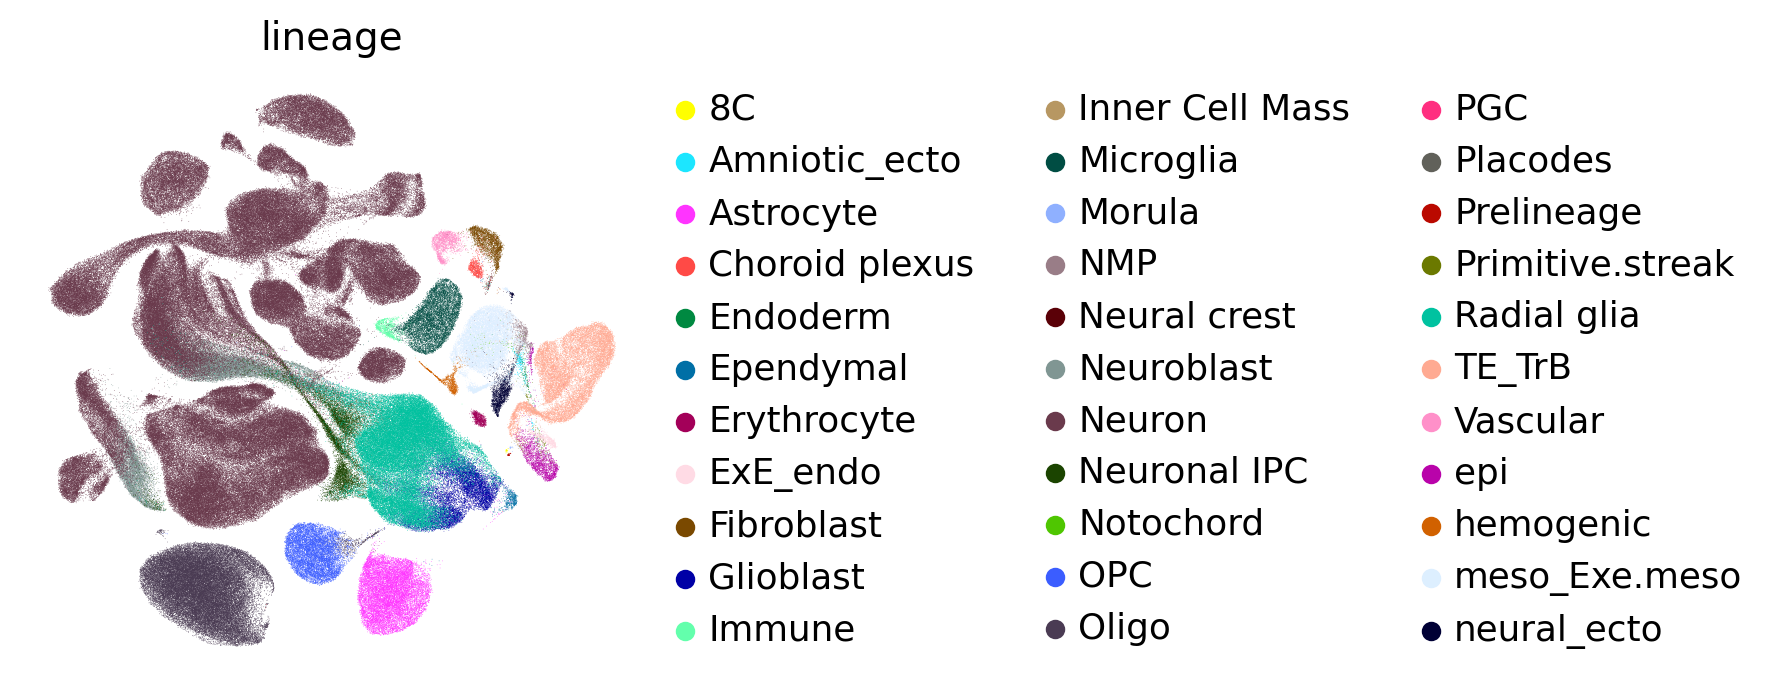

In [50]:
plt.figure()
sc.pl.umap(combined_adata, color="lineage",  frameon=False, show=True)

In [38]:
sample = sc.read_h5ad('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251015_data_re_ref_10x_newversion_dnbctools/output/combined_samples.h5ad')

In [39]:
sample

AnnData object with n_obs × n_vars = 15711 × 33456
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'orig.ident', 'is_original_query', 'original_query_id', 'lineage_pred', 'lineage_uncert', 'reanno_pred', 'reanno_uncert'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_lineage', 'X_umap_reanno'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [51]:
counts_matrix = sample.layers["counts"].toarray()
adata3 = sc.AnnData(X=counts_matrix, obs=sample.obs.copy(), var=sample.var.copy(), layers={'counts': counts_matrix})
adata3 = remove_sparsity(adata3)
all_genes = combined_adata.var_names
missing_genes = all_genes.difference(adata3.var_names)
missing_data = np.zeros((adata3.shape[0], len(missing_genes)))
adata3_df = pd.DataFrame(adata3.X, columns=adata3.var_names, index=adata3.obs_names)
missing_df = pd.DataFrame(missing_data, columns=missing_genes, index=adata3.obs_names)
adata3_combined_df = pd.concat([adata3_df, missing_df], axis=1)
adata3_combined_df = adata3_combined_df[all_genes]
adata3_extended = sc.AnnData(
    X=adata3_combined_df.values, 
    obs=adata3.obs,
    var=pd.DataFrame(index=all_genes),
    layers={'counts': adata3_combined_df.values})
adata3_extended.var['features'] = sample.var.reindex(all_genes).index
target_adata = adata3_extended.copy()
target_adata.obs['lineage'] = 'Unknown'
target_adata.obs['dataset'] = target_adata.obs['sample']
scpoli_query = scPoli.load_query_data(
    adata=target_adata,
    reference_model=scpoli_model,
    labeled_indices=[],
)
scpoli_query.train(
    n_epochs=50,
    pretraining_epochs=40,
    eta=5
)
print(target_adata.X.dtype)  # This is likely the x tensor
target_adata.X = target_adata.X.astype(np.float32)
print(target_adata.obs.dtypes)  # Check types in the annotations/metadata
print(target_adata.var.dtypes)  # Check types in the variable features (genes)
#Label transfer from reference to query
results_dict = scpoli_query.classify(target_adata, scale_uncertainties=True)
from sklearn.metrics import classification_report
# check the label transfer performance achieved
for i in range(len("lineage")):
    preds = results_dict["lineage"]["preds"]
    results_dict["lineage"]["uncert"]
    classification_df = pd.DataFrame(
        classification_report(
            y_true=target_adata.obs["lineage"],
            y_pred=preds,
            output_dict=True,
        )
    ).transpose()
print(classification_df)


INFO:scarches.trainers.scpoli.trainer:GPU available: False


Embedding dictionary:
 	Num conditions: [5]
 	Embedding dim: [20]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 20
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 20
	Output Layer in/out:  45 2000 

The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
Initializing dataloaders
Starting training
 |████████████████----| 80.0%  - val_loss: 1364.30 - val_cvae_loss: 1364.30
Initializing unlabeled prototypes with Leiden with an unknown number of  clusters.
Clustering succesful. Found 19 clusters.
 |████████████████████| 100.0%  - val_loss: 1356.66 - val_cvae_loss: 1356.66 - val_prototype_loss:    0.00 - val_unlabeled_loss:    0.12
float64


<Axes: title={'center': 'lineage_pred'}, xlabel='UMAP1', ylabel='UMAP2'>

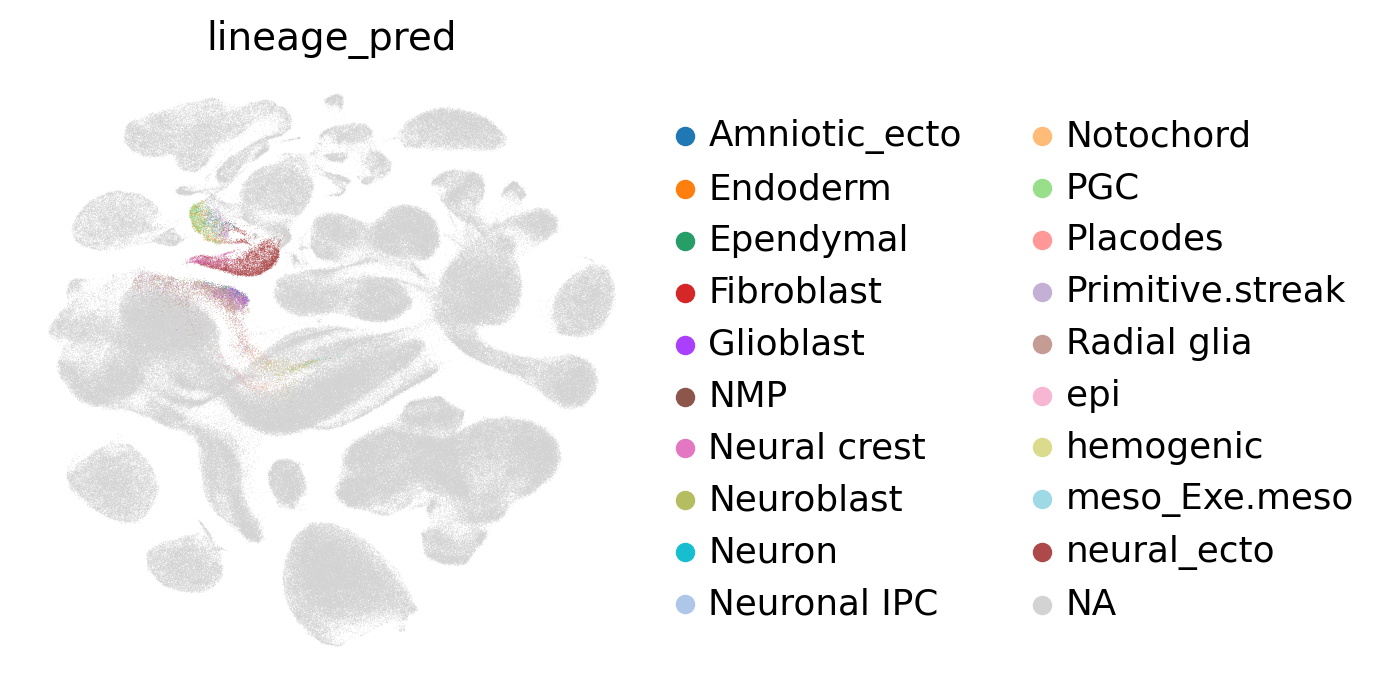

In [52]:
#get latent representation of reference data
scpoli_query.model.eval()
data_latent_source = scpoli_query.get_latent(
    combined_adata,
    mean=True
)

adata_latent_source = sc.AnnData(data_latent_source)
adata_latent_source.obs = combined_adata.obs.copy()

#get latent representation of query data
data_latent= scpoli_query.get_latent(
    target_adata,
    mean=True
)

adata_latent = sc.AnnData(data_latent)
adata_latent.obs = target_adata.obs.copy()

#get label annotations
adata_latent.obs['lineage_pred'] = results_dict['lineage']['preds'].tolist()
adata_latent.obs['lineage_uncert'] = results_dict['lineage']['uncert'].tolist()
adata_latent.obs['classifier_outcome'] = (
    adata_latent.obs['lineage_pred'] == adata_latent.obs['lineage']
)

#get prototypes
labeled_prototypes = scpoli_query.get_prototypes_info()
labeled_prototypes.obs['study'] = 'labeled prototype'
unlabeled_prototypes = scpoli_query.get_prototypes_info(prototype_set='unlabeled')
unlabeled_prototypes.obs['study'] = 'unlabeled prototype'

#join adatas
adata_latent_full = adata_latent_source.concatenate(
    [adata_latent, labeled_prototypes, unlabeled_prototypes],
    batch_key='query'
)
adata_latent_full.obs['lineage_pred'][adata_latent_full.obs['query'].isin(['0'])] = np.nan
sc.pp.neighbors(adata_latent_full, n_neighbors=15)
sc.tl.umap(adata_latent_full)
adata_no_prototypes = adata_latent_full[adata_latent_full.obs['query'].isin(['0', '1'])]
sc.pl.umap(
    adata_no_prototypes,
    color='lineage_pred',
    show=False,
    frameon=False,
)

In [53]:
sc.pp.neighbors(adata_latent)
sc.tl.leiden(adata_latent)
sc.tl.umap(adata_latent)

<Axes: title={'center': 'sample'}, xlabel='UMAP1', ylabel='UMAP2'>

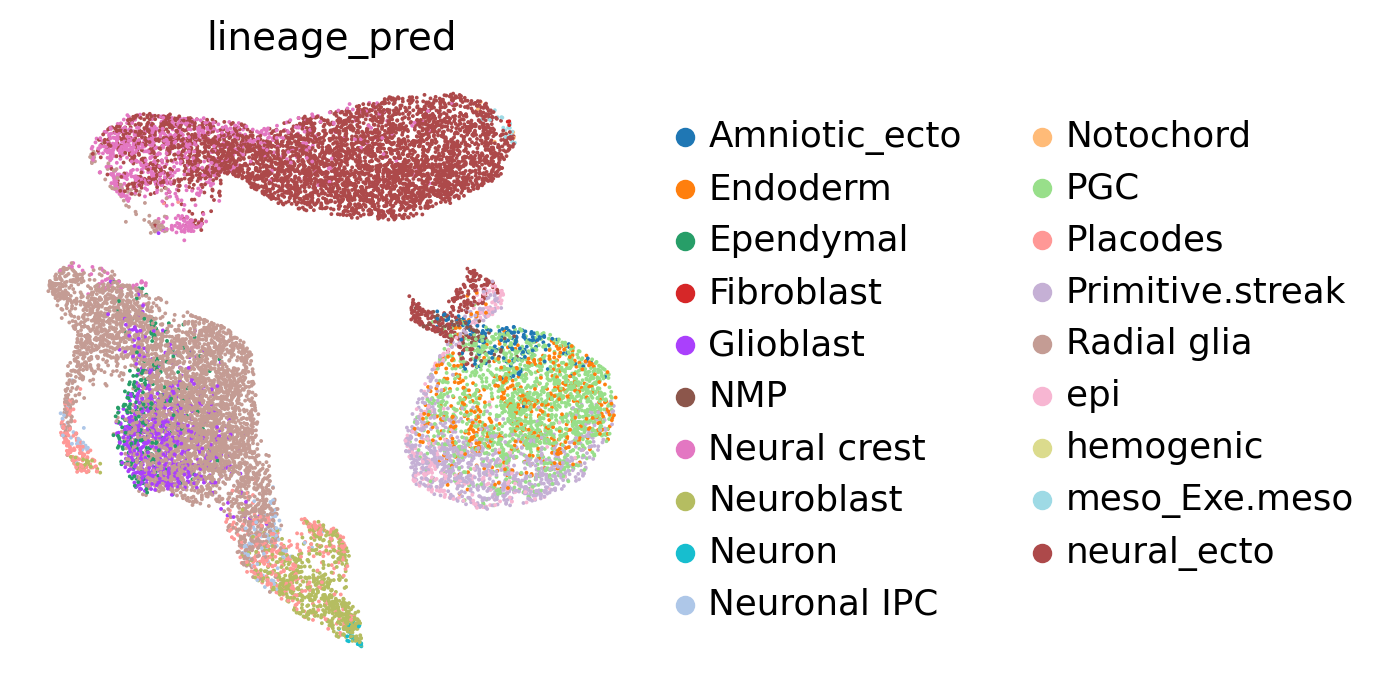

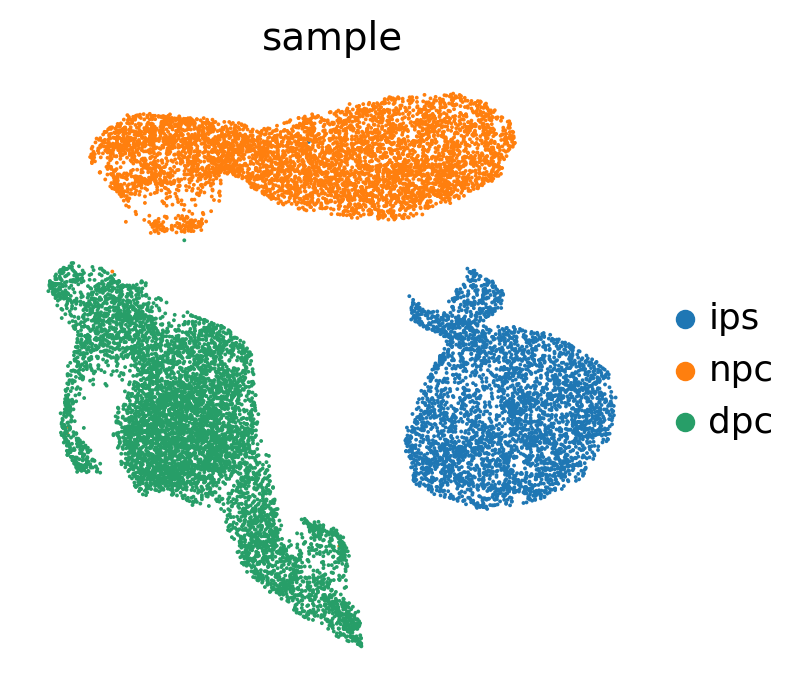

In [54]:
sc.pl.umap(
    adata_latent,
    color='lineage_pred',
    show=False,
    frameon=False,
)
sc.pl.umap(
    adata_latent,
    color='sample',
    show=False,
    frameon=False,
)

In [46]:
adata_latent

AnnData object with n_obs × n_vars = 15711 × 10
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'orig.ident', 'is_original_query', 'original_query_id', 'lineage_pred', 'lineage_uncert', 'reanno_pred', 'reanno_uncert', 'lineage', 'dataset', 'conditions_combined', 'classifier_outcome'
    uns: 'neighbors', 'leiden', 'umap', 'lineage_pred_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'